# Transformer V11-norm-v2 — 推理打分 Notebook

## 提交方式二: .py 训练 + .ipynb 推理

模型定义、数据管线全部在 `transformer_train.py`（单一事实来源），
本 notebook 通过 `from transformer_train import ...` 复用，仅包含推理特有逻辑。

平台调用 `main(datasources, start_date, end_date)` 进行推理:
- **公榜阶段**: 使用提交的 `transformer_model.json` 权重直接推理
- **私榜阶段**: 平台先用 `transformer_train.py` 从零重训, 再用本 notebook 推理

## 模型架构 (V11-norm-v2)

- SpectralFilter1D: 可学习频域滤波 (FFT → MLP → iFFT)
- Conv Stem + ClusterEmbed (5 类股价聚类) + Positional + ToD Embedding
- Transformer Encoder: 3 层, d=96, head=4, ff=192, pre-norm
- Attn Gate: softmax 时间维加权聚合 → MLP → scalar
- DAE 辅助: mask 15% + Gaussian noise σ=0.10 → 重建 MSE
- EMA: decay=0.999

## 预处理管线 (复用 transformer_train.build_dataset)

1. bid/ask 零值 → close 填充
2. 价格 ÷ pre_close (日级归一化)
3. log1p (量) / log (价) 变换
4. 量 ÷ daily_max (日级归一化)
5. 240-bar 窗口 → z-score (复用训练集 mean/std)

## 非线性因子变换

使用 rank → normal (Probit) 变换对抗 BARRA 线性回归中性化。
变换保持截面排序不变 (Spearman IC 不变), 只改变分布形态。

In [9]:
# ============================================================
# 导入依赖 (从 transformer_train 复用模型定义与数据管线)
# ============================================================
import os, json, sys, time
import numpy as np
import pandas as pd
import dai
import torch
import torch.nn.functional as F
import structlog

from transformer_train import (
    MODEL_PATH, BATCH,
    StockTransformer, build_dataset, pool, load_model,
)

logger = structlog.get_logger()


# ============================================================
# 非线性因子变换: rank → normal (Probit)
# ============================================================
# 目的: 对抗平台 BARRA 线性回归中性化。
#   平台评估管线: 3σ 截尾 → z-score → BARRA+行业 OLS 回归 → 取残差
#   OLS 只能移除线性相关; 对原始分数做非线性 rank→normal 变换后,
#   部分预测信号在回归残差中得以保留, 不被完全中性化。
#
# 变换保持截面排序不变 (Spearman IC 不变), 只改变分布形态。

TRANSFORM_METHOD = "rank_normal"  # "rank_normal" | "none"


def _norm_ppf(p):
    """标准正态分位数函数 (Acklam 算法, 不依赖 scipy)。"""
    p = np.asarray(p, np.float64)
    a1, a2, a3 = -39.6968302866538, 220.9460984245205, -275.9285104469687
    a4, a5, a6 = 138.3577518672690, -30.66479806614716, 2.506628277459239
    b1, b2, b3 = -54.47609879822406, 161.5858368580409, -155.6989798598866
    b4, b5 = 66.80131188771972, -13.28068155288572
    c1, c2, c3 = -7.784894002430293e-03, -0.3223964580411365, -2.400758277161838
    c4, c5, c6 = -2.549732539343734, 4.374664141464968, 2.938163982698783
    d1, d2 = 7.784695709041462e-03, 0.3224671290700398
    d3, d4 = 2.445134137142996, 3.754408661907416

    result = np.full_like(p, np.nan, dtype=np.float64)
    low = (p > 0.0) & (p < 0.02425)
    if low.any():
        q = np.sqrt(-2.0 * np.log(p[low]))
        num = ((((c1 * q + c2) * q + c3) * q + c4) * q + c5) * q + c6
        den = (((d1 * q + d2) * q + d3) * q + d4) * q + 1.0
        result[low] = num / den
    high = (p >= 0.02425) & (p <= 0.97575)
    if high.any():
        q = p[high] - 0.5; r = q * q
        num = ((((a1 * r + a2) * r + a3) * r + a4) * r + a5) * r + a6
        den = ((((b1 * r + b2) * r + b3) * r + b4) * r + b5) * r + 1.0
        result[high] = q * num / den
    upper = (p > 0.97575) & (p < 1.0)
    if upper.any():
        q = np.sqrt(-2.0 * np.log(1.0 - p[upper]))
        num = ((((c1 * q + c2) * q + c3) * q + c4) * q + c5) * q + c6
        den = (((d1 * q + d2) * q + d3) * q + d4) * q + 1.0
        result[upper] = -num / den
    return result


def _rank_to_normal(series):
    """单日截面: rank → Probit → 正态分布。"""
    n = len(series)
    if n < 2:
        return pd.Series(np.zeros(n, dtype=np.float64), index=series.index)
    ranks = series.rank(method="average")
    p = np.clip((ranks.values - 0.5) / n, 1e-15, 1.0 - 1e-15)
    return pd.Series(_norm_ppf(p), index=series.index)


def transform_factor(result_df, method="rank_normal"):
    """对因子分数做截面非线性变换。"""
    if method == "none":
        return result_df
    df = result_df.copy()
    df["score"] = df.groupby("date", sort=False)["score"].transform(
        _rank_to_normal)
    return df


logger.info("非线性变换配置已加载", method=TRANSFORM_METHOD)

[2026-08-02 22:19:22] [info     ] 非线性变换配置已加载                     method=rank_normal


In [10]:
# 模型定义 (StockTransformer, SpectralFilter1D, ClusterEmbed) 和
# 数据管线 (build_dataset, pool, load_model) 从 transformer_train 导入,
# 此处不再重复定义。详见 transformer_train.py。

In [11]:
# ============================================================
# ★ 推理入口: main(datasources, start_date, end_date)
# ============================================================
# 平台调用此函数, 自动替换 datasources / start_date / end_date。
#
# 参数:
#   datasources: dict, {"bar1m": 验证集表名}
#   start_date:  推理开始日期, 如 "2024-01-01 00:00:00"
#   end_date:    推理结束日期, 如 "2024-12-31 23:59:59"
#
# 返回:
#   DataFrame [date, instrument, score], score 为因子分数

def main(datasources, start_date, end_date):
    # ---- 1. 准备 ----------------
    table = datasources["bar1m"]  # ★ 推理使用 datasources (平台替换为验证集表)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if not os.path.exists(MODEL_PATH):
        raise FileNotFoundError(
            f"未找到模型文件 {MODEL_PATH}。请确保 transformer_train.py 已完成训练。")

    # ---- 2. 加载模型权重 + 配置 ----
    ckpt = load_model(MODEL_PATH, map_location=device)
    stats = (np.asarray(ckpt["mean"], np.float32),
             np.asarray(ckpt["std"], np.float32))
    saved_flags = ckpt.get("feature_flags", {})
    use_sf = ckpt.get("spectral_filter", True)
    use_ce = ckpt.get("use_cluster_emb", True)
    n_clusters = ckpt.get("n_clusters", 5)

    # 归一化配置 (训练时保存, 推理时复用)
    price_norm = ckpt.get("price_norm_mode", "pre_close")
    vol_norm   = ckpt.get("vol_norm_mode", "daily_max")
    logger.info("归一化配置", price_norm=price_norm, vol_norm=vol_norm)

    # 聚类边界 (训练时从 bar1d 收盘价计算, 推理时复用)
    cluster_boundaries = None
    if use_ce:
        cb_list = ckpt.get("cluster_boundaries", [])
        if cb_list:
            cluster_boundaries = np.asarray(cb_list, np.float32)
            logger.info("已加载聚类边界", n_clusters=n_clusters,
                        boundaries=[f"{b:.2f}" for b in cluster_boundaries])

    # ---- 3. 构建模型 ----
    model = StockTransformer(
        **ckpt["model_cfg"],
        session_aware=saved_flags.get("session_aware", False),
        use_preclose_gate=saved_flags.get("use_preclose_gate", False),
        use_tod_emb=saved_flags.get("use_tod_emb", True),
        use_prenorm=saved_flags.get("use_prenorm", True),
        use_spectral_filter=use_sf,
        use_cluster_emb=use_ce,
        n_clusters=n_clusters,
    ).to(device)
    model.load_state_dict(ckpt["state_dict"])
    model.eval()
    logger.info("模型已加载", spectral_filter=use_sf, cluster_emb=use_ce)

    # ---- 4. 构建推理数据集 (复用 transformer_train.build_dataset) ----
    Xte, _, idx_df, _, cluster_ids = build_dataset(
        table, start_date, end_date, "infer",
        pool(start_date, end_date), stats,
        cluster_boundaries=cluster_boundaries,
        price_norm_mode=price_norm, vol_norm_mode=vol_norm)
    logger.info("推理数据构建完成", samples=len(idx_df))

    # ---- 5. 批量推理 ----
    preds = []
    with torch.no_grad():
        for i in range(0, len(idx_df), BATCH):
            xb = torch.from_numpy(Xte[i:i + BATCH]).to(device)
            # 仅当启用聚类嵌入且有有效边界时才传 cluster_ids
            if use_ce and cluster_boundaries is not None:
                cid_b = torch.from_numpy(
                    cluster_ids[i:i + BATCH]).to(device)
            else:
                cid_b = None
            preds.append(model(
                xb, cluster_ids=cid_b, return_recon=False).cpu().numpy())
    preds = np.concatenate(preds).astype(np.float64)

    # 逆 log1p 变换 (训练标签是 log1p 空间)
    if ckpt.get("target_transform") == "log1p":
        preds = np.expm1(preds)
    idx_df["score"] = preds

    # ---- 6. 与成分股对齐 + 清洗 ----
    stk = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={"date": [start_date, end_date]}).df()
    result = (pd.merge(idx_df, stk, on=["date", "instrument"], how="inner")
              .replace([np.inf, -np.inf], np.nan)
              .dropna(subset=["score"])
              .drop_duplicates(["date", "instrument"])
              [["date", "instrument", "score"]]
              .reset_index(drop=True))
    logger.info("分数构建完成", rows=len(result))

    # ---- 7. 非线性变换 (对抗 BARRA 线性回归中性化) ----
    result = transform_factor(result, method=TRANSFORM_METHOD)
    logger.info("非线性变换完成", method=TRANSFORM_METHOD, rows=len(result))

    return result

[2026-08-02 22:19:22] [info     ] 归一化配置                          price_norm=pre_close vol_norm=daily_max
[2026-08-02 22:19:22] [info     ] 已加载聚类边界                        boundaries=['13.89', '32.52', '82.47', '193.10'] n_clusters=5
[2026-08-02 22:19:22] [info     ] 模型已加载                          cluster_emb=True spectral_filter=True
[2026-08-02 22:19:36] [info     ] 批次完成                           batch=1/9 batch_samples=36079 cum_samples=36079
[2026-08-02 22:19:49] [info     ] 批次完成                           batch=2/9 batch_samples=36162 cum_samples=72241
[2026-08-02 22:20:01] [info     ] 批次完成                           batch=3/9 batch_samples=36279 cum_samples=108520
[2026-08-02 22:20:14] [info     ] 批次完成                           batch=4/9 batch_samples=36240 cum_samples=144760
[2026-08-02 22:20:26] [info     ] 批次完成                           batch=5/9 batch_samples=35685 cum_samples=180445
[2026-08-02 22:20:38] [info     ] 批次完成                           batch=6/9 batch_samples=36258 cu

时段,IC
2024-01-15~2024-02-08,-0.0107
2024-09-24~2024-10-08,0.0757

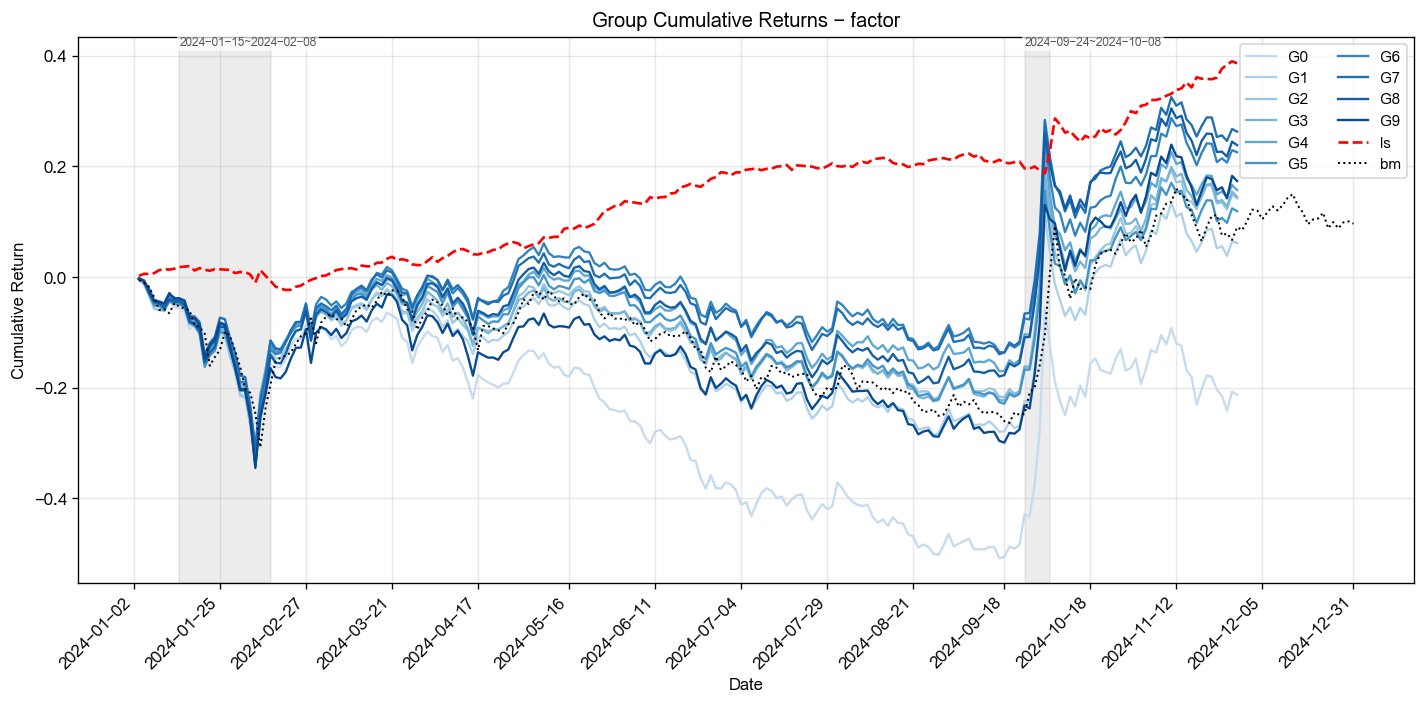
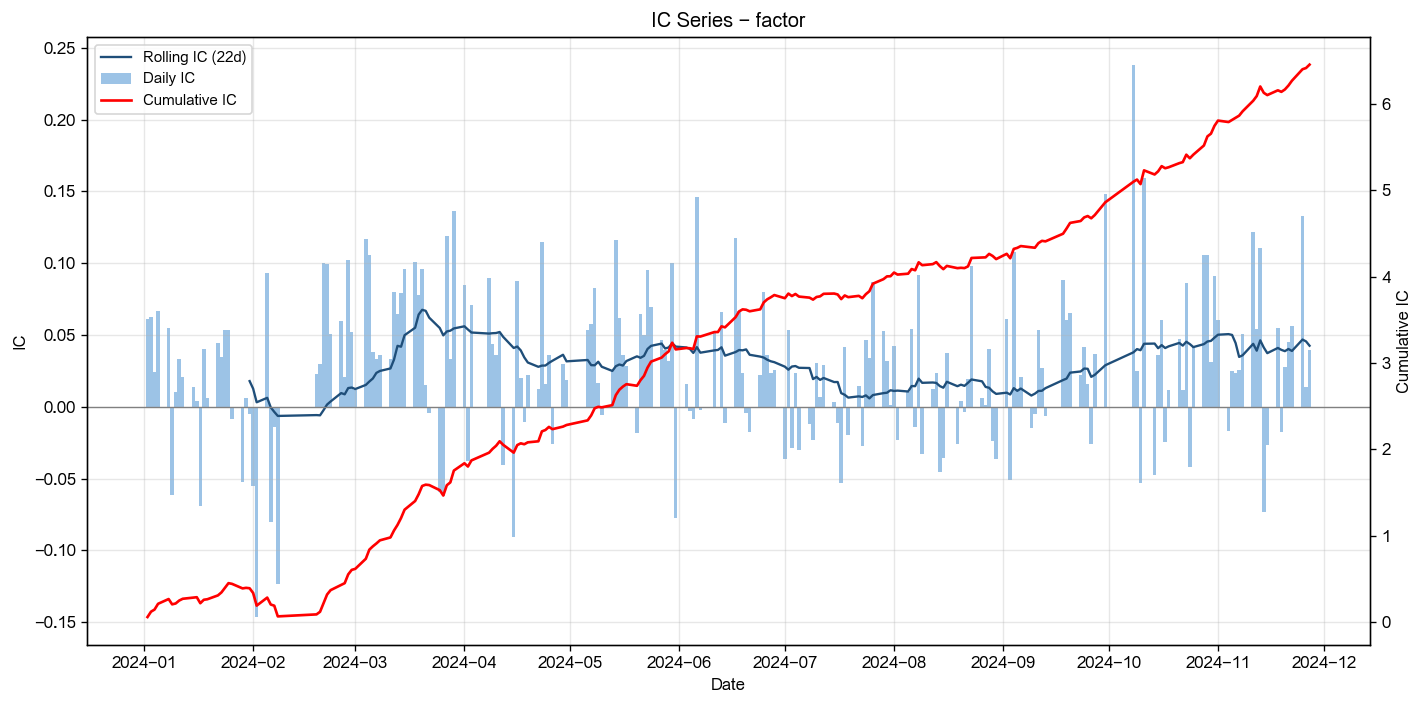
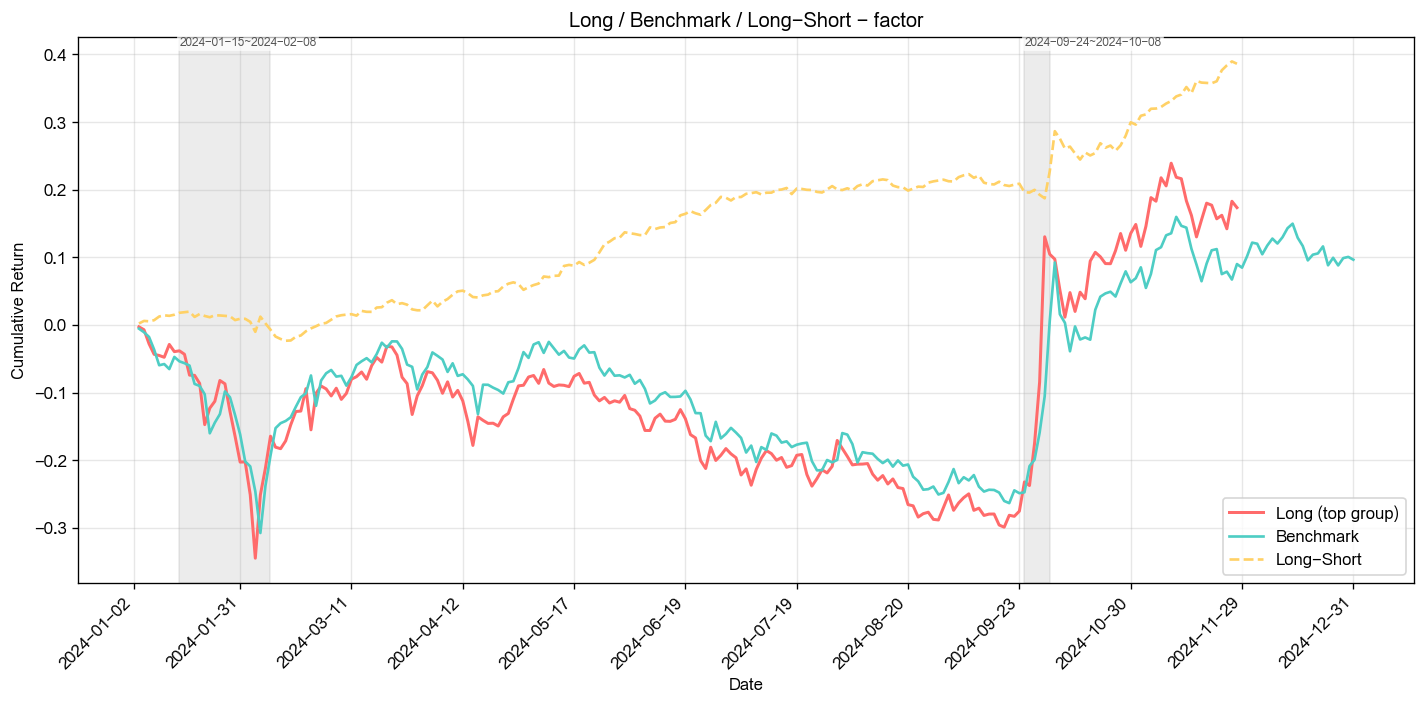
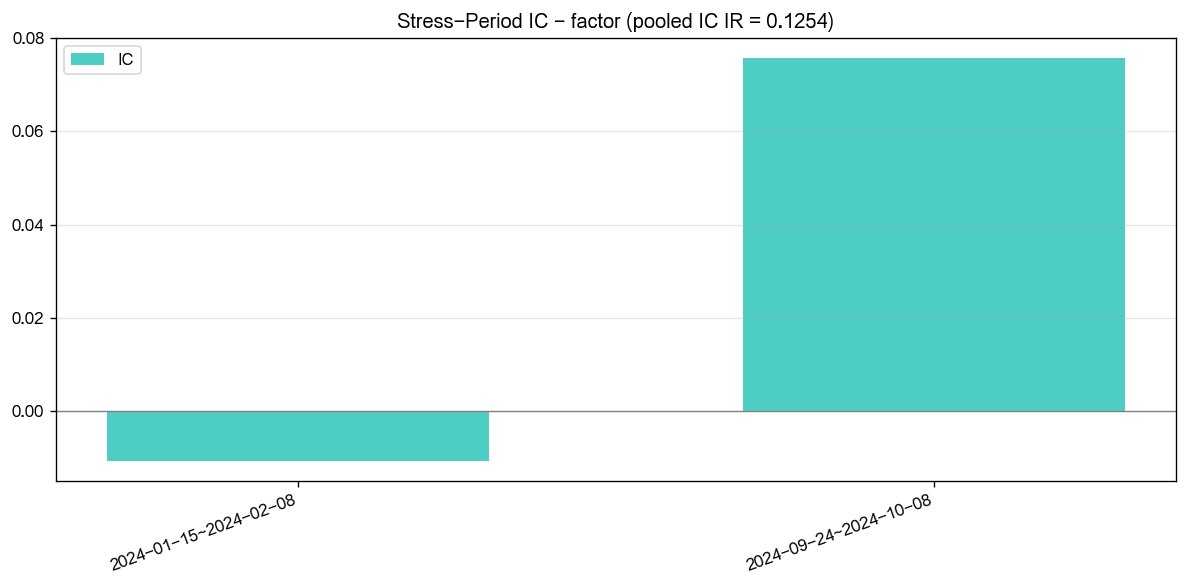
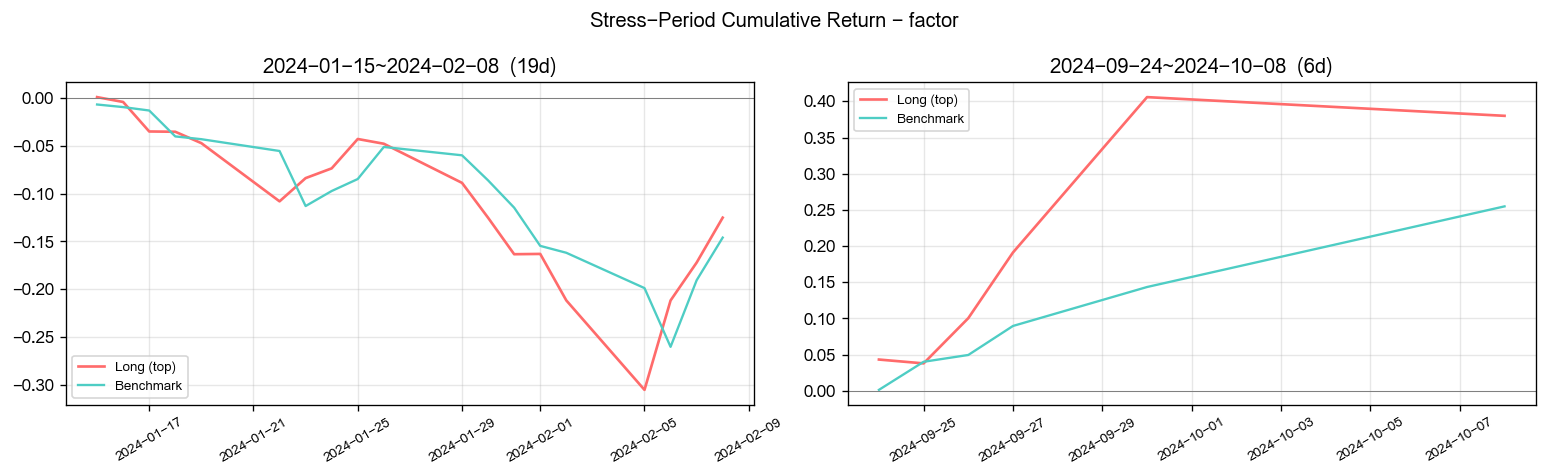

[2026-08-02 22:21:35] [warning  ] 未传入因子池，跳过因子池回归检验
[2026-08-02 22:21:35] [warning  ] 返回的Outputs实例(size=35322931) 大于 64K, 将不会被缓存
[2026-08-02 22:21:35] [info     ] bigalpha_eval.v4 运行完成 [8.500s].


In [12]:
# ============================================================
# 本地测试 (平台不会执行此 cell)
# ============================================================
if __name__ == "__main__":
    from bigmodule import M

    # ★ 本地测试: 硬编码训练表名 (训练不使用 datasources)
    TRAIN_TABLE = "bigalpha_2026_stock_bar1m"
    datasources = {"bar1m": TRAIN_TABLE}

    # 如果模型不存在, 先训练
    if not os.path.exists(MODEL_PATH):
        logger.info("未发现模型文件, 开始训练...")
        import transformer_train
        transformer_train.train_and_save({"bar1m": TRAIN_TABLE})

    # 推理 + 评估
    start_date, end_date = "2024-01-01 00:00:00", "2024-12-31 23:59:59"
    score_data = main(datasources, start_date, end_date)
    print(score_data.head(10))

    logger.info("开始本地评估")
    result = M.bigalpha_eval._latest(factor_data=score_data, show=True)